# **nalara.academy**

## **Modul 3 - AI & Machine Learning**
### **Sesi 1: Demistifikasi AI & Peta Dunia Pembelajaran Mesin**

### **📌 Pengantar Sesi**
Banyak pemula terburu-buru mempelajari algoritma AI yang rumit tanpa memahami dulu peta besar
bidang ini, dan jenis data apa yang sedang mereka hadapi. Sebelum menyentuh gambar atau teks
(data *unstructured*), kita akan membangun kepercayaan diri terlebih dahulu menggunakan data
**Structured** (data rapi berbentuk tabel) — jenis data yang paling ramah untuk pemula.

Di sesi ini kita akan menempuh **pipeline Machine Learning yang lengkap dan runtut**:
1. Pengenalan konsep AI, ML, dan Deep Learning
2. Data Loading
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Pengecekan Class Imbalance
7. Pemodelan (Training & Evaluasi)

## **🧠 1.1 AI vs ML vs Deep Learning**

Ketiga istilah ini sering tertukar, padahal mereka punya hubungan hierarki seperti lingkaran
bersarang (nested circle):

```
┌─────────────────────────────────────────┐
│   ARTIFICIAL INTELLIGENCE (AI)           │
│   "Payung besar" — segala upaya membuat  │
│   mesin berperilaku cerdas               │
│                                           │
│   ┌───────────────────────────────────┐ │
│   │  MACHINE LEARNING (ML)             │ │
│   │  Metode AI yang belajar dari DATA  │ │
│   │  bukan diprogram aturan secara     │ │
│   │  eksplisit                         │ │
│   │                                     │ │
│   │   ┌─────────────────────────────┐ │ │
│   │   │  DEEP LEARNING (DL)         │ │ │
│   │   │  Evolusi ML menggunakan     │ │ │
│   │   │  Neural Network berlapis    │ │ │
│   │   │  banyak (deep)              │ │ │
│   │   └─────────────────────────────┘ │ │
│   └───────────────────────────────────┘ │
└─────────────────────────────────────────┘
```

- **AI** → Tujuan akhirnya: mesin yang berperilaku cerdas. Termasuk rule-based system jadul
  sekalipun (misal: chatbot if-else) sudah masuk kategori AI.
- **ML** → AI yang "belajar" pola dari data historis, alih-alih diberi aturan manual.
- **DL** → ML yang menggunakan arsitektur Neural Network sangat dalam, biasanya butuh data
  jauh lebih banyak, tapi sanggup menangani data *unstructured* mentah (gambar, suara, teks)
  tanpa banyak campur tangan manusia.

Di sesi ini & sesi berikutnya kita akan fokus dulu di lapisan **ML Klasik** sebelum nanti
masuk ke Deep Learning.

## **📊 1.2 Structured vs Unstructured Data**

| | Structured Data | Unstructured Data |
|---|---|---|
| Bentuk | Tabel rapi (baris & kolom) | Gambar, teks bebas, suara, video |
| Contoh | Excel data penjualan, data sensor | Foto produk, rekaman suara CS |
| Disukai komputer? | Sangat disukai — tinggal dihitung | "Liar" — perlu diterjemahkan dulu |
| Algoritma cocok | ML Klasik (Scikit-Learn) | Umumnya Deep Learning |

Gambar adalah salah satu bentuk *unstructured data* paling klasik: secara default ia hanyalah
matriks piksel raksasa tanpa struktur kolom yang bermakna bagi statistik biasa. Inilah alasan
**Computer Vision** lahir — sebagai jembatan untuk "menjinakkan" data visual yang liar tersebut
menjadi sesuatu yang bisa diproses algoritma.

Di sesi ini kita mulai dari yang paling jinak dulu: **data Structured**.

## **🧩 1.3 Empat Kuadran Machine Learning**

| Jenis | Analogi | Ciri Khas |
|---|---|---|
| **Supervised Learning** | Belajar pakai kunci jawaban | Data punya label/target yang sudah diketahui |
| **Unsupervised Learning** | Belajar tanpa kunci jawaban | Mencari pola/kelompok tersembunyi sendiri |
| **Semi-Supervised Learning** | Kunci jawaban sedikit, sisanya menebak | Sebagian data berlabel, sebagian besar tidak |
| **Reinforcement Learning** | Coba-coba, dapat hadiah/hukuman | Belajar lewat trial-and-error berbasis *reward* |

Fokus utama modul ini adalah **Supervised Learning** — karena paling umum dipakai di industri
dan paling mudah dipahami pemula: kita punya data input (X) dan jawaban yang benar (y), lalu
melatih model untuk menebak y dari X.

## **💻 Praktik: Hello World Machine Learning**

### **📦 Dataset: Clothes Size Prediction**

Dataset ini berisi data ukuran tubuh (berat, tinggi, usia) beserta ukuran baju yang sesuai.
Tugas kita: melatih model untuk **menebak ukuran baju** berdasarkan atribut tubuh seseorang —
sebuah kasus klasifikasi *Supervised Learning* dengan data Structured.

| Info | Detail |
|------|--------|
| 📌 Sumber | Kaggle |
| 👤 Author | tourist55 |
| 🔗 Link | https://www.kaggle.com/datasets/tourist55/clothessizeprediction/data |
| 🎯 Target | `size` (ukuran baju) |

In [1]:
# ============================================================
# SETUP KAGGLE API TOKEN (lakukan sekali saja)
#
# Kaggle menggunakan token langsung (tanpa file kaggle.json).
# Cara mendapatkan token:
# 1. Login ke kaggle.com -> klik foto profil -> Settings
# 2. Scroll ke bagian API -> klik "Create New API Token"
# 3. Salin token yang muncul
#
# Set sebagai environment variable di terminal SEBELUM membuka notebook:
#   Windows PowerShell : $env:KAGGLE_USERNAME="username_anda"; $env:KAGGLE_KEY="token_anda"
#   Mac/Linux           : export KAGGLE_USERNAME=username_anda; export KAGGLE_KEY=token_anda
# ============================================================

import subprocess, os, zipfile

subprocess.run(["pip", "install", "kaggle", "--quiet"], check=True)

os.makedirs("dataset_baju", exist_ok=True)

print("⏳ Mengunduh dataset dari Kaggle...")
os.system("kaggle datasets download -d tourist55/clothessizeprediction -p dataset_baju --quiet")

zip_files = [f for f in os.listdir("dataset_baju") if f.endswith(".zip")]
if zip_files:
    zip_path = os.path.join("dataset_baju", zip_files[0])
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("dataset_baju")
    print("✅ Dataset berhasil diunduh & diekstrak ke folder 'dataset_baju/'")
else:
    print("❌ Gagal mengunduh. Pastikan KAGGLE_USERNAME & KAGGLE_KEY sudah di-set.")

⏳ Mengunduh dataset dari Kaggle...
✅ Dataset berhasil diunduh & diekstrak ke folder 'dataset_baju/'


### **Importasi Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


## **🔎 2. Data Loading — Mengenal Data Sebelum Diapa-apakan**

Sebelum membersihkan apapun, kita wajib **melihat dulu** bentuk data mentahnya: berapa baris,
berapa kolom, tipe data apa saja, dan apakah ada keanehan sekilas mata.

In [3]:
PATH_CSV = "dataset_baju/final_test.csv"  # sesuaikan jika nama file berbeda setelah ekstrak

# Jika ada lebih dari satu file csv hasil ekstrak, tampilkan dulu daftarnya
for f in os.listdir("dataset_baju"):
    if f.endswith(".csv"):
        print("📄 Ditemukan file CSV:", f)

📄 Ditemukan file CSV: final_test.csv


In [4]:
# Sesuaikan nama file di sini berdasarkan output cell sebelumnya
import glob
csv_path = glob.glob("dataset_baju/*.csv")[0]

df = pd.read_csv(csv_path)

print(f"📐 Ukuran data: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

📐 Ukuran data: 119734 baris, 4 kolom


,weight,age,height,size
0,62,28.0,172.72,XL
1,59,36.0,167.64,L
2,61,34.0,165.10,M
3,65,27.0,175.26,L
4,62,45.0,172.72,M


In [5]:
print("ℹ️  INFORMASI TIPE DATA & NON-NULL COUNT")
print("=" * 50)
df.info()

ℹ️  INFORMASI TIPE DATA & NON-NULL COUNT
<class 'pandas.DataFrame'>
RangeIndex: 119734 entries, 0 to 119733
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   weight  119734 non-null  int64  
 1   age     119477 non-null  float64
 2   height  119404 non-null  float64
 3   size    119734 non-null  str    
dtypes: float64(2), int64(1), str(1)
memory usage: 3.7 MB


In [6]:
print("📊 STATISTIK DESKRIPTIF KOLOM NUMERIK")
df.describe()

📊 STATISTIK DESKRIPTIF KOLOM NUMERIK


,weight,age,height
count,119734.000000,119477.000000,119404.000000
mean,61.756811,34.027311,165.805794
std,9.944863,8.149447,6.737651
min,22.000000,0.000000,137.160000
25%,55.000000,29.000000,160.020000
50%,61.000000,32.000000,165.100000
75%,67.000000,37.000000,170.180000
max,136.000000,117.000000,193.040000


## **🧹 3. Data Cleaning**

Data mentah dari dunia nyata (apalagi hasil crowdsourcing seperti dataset ini) hampir selalu
punya masalah: nilai kosong (*missing values*), duplikasi baris, atau outlier ekstrem yang
tidak masuk akal secara fisik (misalnya berat badan 500kg).

Kita akan bersihkan secara bertahap, **dan menjelaskan alasan di setiap keputusan**, bukan
sekadar `dropna()` membabi buta.

### **3.1 Mengecek Missing Values**

In [7]:
missing = df.isnull().sum()
missing_persen = (missing / len(df)) * 100

ringkasan_missing = pd.DataFrame({
    "Jumlah Missing": missing,
    "Persentase (%)": missing_persen.round(2)
}).sort_values("Jumlah Missing", ascending=False)

print("🔍 RINGKASAN MISSING VALUES PER KOLOM")
print("=" * 45)
print(ringkasan_missing)

🔍 RINGKASAN MISSING VALUES PER KOLOM
        Jumlah Missing  Persentase (%)
height             330            0.28
age                257            0.21
weight               0            0.00
size                 0            0.00


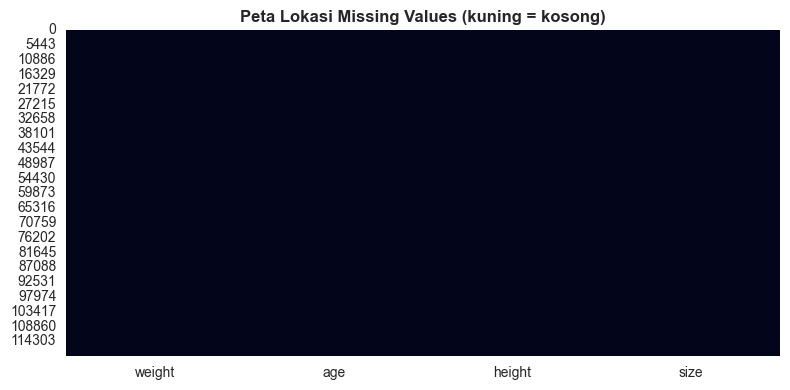

In [8]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="rocket")
plt.title("Peta Lokasi Missing Values (kuning = kosong)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Keputusan penanganan missing values:**
- Jika sebuah kolom punya persentase missing yang kecil (<5%), baris yang kosong cukup
  **dihapus** (`dropna`) — karena menghapusnya tidak akan banyak mengurangi informasi.
- Jika persentase missing cukup besar pada kolom numerik, kita pertimbangkan **imputasi**
  (isi dengan median, karena median lebih tahan terhadap outlier dibanding mean).
- Kita TIDAK akan asal isi dengan angka 0, karena bisa menyesatkan model (misal tinggi badan
  0 cm tidak masuk akal secara fisik, beda makna dengan "datanya memang kosong").

In [9]:
# Strategi: drop baris yang seluruh kolom pentingnya kosong,
# lalu imputasi median untuk kolom numerik yang masih tersisa missing-nya.
kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Kolom numerik yang akan dicek: {kolom_numerik}")

# Hapus baris yang target labelnya (size) kosong -- baris ini tidak berguna untuk supervised learning
if "size" in df.columns:
    sebelum = len(df)
    df = df.dropna(subset=["size"])
    sesudah = len(df)
    print(f"🗑️  Baris dengan target 'size' kosong dihapus: {sebelum - sesudah} baris")

# Imputasi median untuk sisa kolom numerik yang masih kosong
for kolom in kolom_numerik:
    if kolom in df.columns and df[kolom].isnull().sum() > 0:
        median_val = df[kolom].median()
        jumlah_kosong = df[kolom].isnull().sum()
        df[kolom] = df[kolom].fillna(median_val)
        print(f"🩹 Kolom '{kolom}': {jumlah_kosong} nilai kosong diisi dengan median ({median_val:.2f})")

print(f"\n✅ Sisa missing values setelah cleaning: {df.isnull().sum().sum()}")

Kolom numerik yang akan dicek: ['weight', 'age', 'height']
🗑️  Baris dengan target 'size' kosong dihapus: 0 baris
🩹 Kolom 'age': 257 nilai kosong diisi dengan median (32.00)
🩹 Kolom 'height': 330 nilai kosong diisi dengan median (165.10)

✅ Sisa missing values setelah cleaning: 0


### **3.2 Mengecek & Menghapus Duplikasi Baris**

In [10]:
jumlah_duplikat = df.duplicated().sum()
print(f"🔁 Jumlah baris duplikat ditemukan: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    df = df.drop_duplicates()
    print(f"🗑️  Baris duplikat berhasil dihapus.")

print(f"📐 Ukuran data setelah penghapusan duplikat: {df.shape}")

🔁 Jumlah baris duplikat ditemukan: 92693
🗑️  Baris duplikat berhasil dihapus.
📐 Ukuran data setelah penghapusan duplikat: (27041, 4)


### **3.3 Mendeteksi & Menangani Outlier**

Outlier adalah nilai ekstrem yang secara fisik tidak masuk akal (misal: tinggi badan 250cm atau
berat badan 2kg untuk orang dewasa). Kita akan visualisasikan dengan **Boxplot** dulu untuk
melihat sebarannya, baru putuskan apakah perlu dipotong (*capping*) atau dihapus.

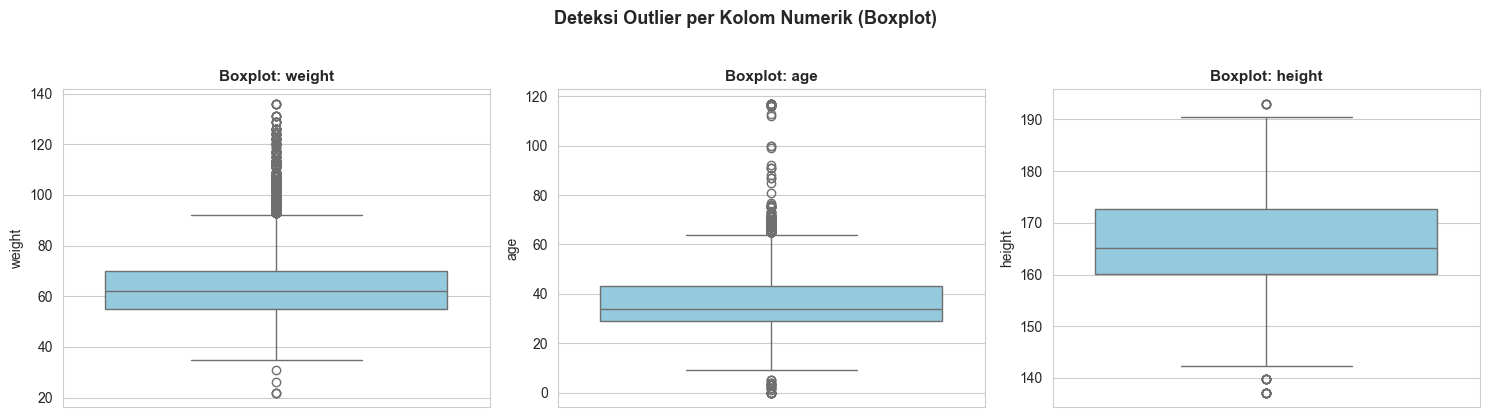

In [11]:
fig, axes = plt.subplots(1, len(kolom_numerik), figsize=(5 * len(kolom_numerik), 4))
if len(kolom_numerik) == 1:
    axes = [axes]

for ax, kolom in zip(axes, kolom_numerik):
    sns.boxplot(y=df[kolom], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot: {kolom}", fontsize=11, fontweight="bold")

plt.suptitle("Deteksi Outlier per Kolom Numerik (Boxplot)", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

In [12]:
def hitung_batas_iqr(series):
    """Menghitung batas bawah & atas outlier menggunakan metode IQR (Interquartile Range)."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas  = q3 + 1.5 * iqr
    return batas_bawah, batas_atas

print("📏 BATAS OUTLIER (METODE IQR) PER KOLOM")
print("=" * 55)

for kolom in kolom_numerik:
    bawah, atas = hitung_batas_iqr(df[kolom])
    jumlah_outlier = ((df[kolom] < bawah) | (df[kolom] > atas)).sum()
    print(f"   {kolom:<10} -> batas wajar: [{bawah:.1f}, {atas:.1f}]  | outlier: {jumlah_outlier} baris")

📏 BATAS OUTLIER (METODE IQR) PER KOLOM
   weight     -> batas wajar: [32.5, 92.5]  | outlier: 905 baris
   age        -> batas wajar: [8.0, 64.0]  | outlier: 310 baris
   height     -> batas wajar: [141.0, 191.8]  | outlier: 21 baris


In [13]:
# Strategi: CAPPING (bukan menghapus) -- nilai yang melewati batas dipangkas ke batas terdekat.
# Alasan memilih capping dibanding drop: data kita tidak terlalu besar, menghapus baris
# berisiko membuang terlalu banyak informasi. Capping menjaga jumlah data tetap utuh
# sambil tetap meredam pengaruh nilai ekstrem terhadap model.

for kolom in kolom_numerik:
    bawah, atas = hitung_batas_iqr(df[kolom])
    df[kolom] = df[kolom].clip(lower=bawah, upper=atas)

print("✅ Outlier berhasil di-capping ke batas wajar (IQR method).")

✅ Outlier berhasil di-capping ke batas wajar (IQR method).


## **🔬 4. Exploratory Data Analysis (EDA)**

Sekarang data sudah bersih. Saatnya benar-benar **memahami isi & pola data** sebelum melatih
model apapun — supaya setiap keputusan feature engineering & pemilihan model didasari bukti,
bukan tebakan.

### **4.1 Distribusi Setiap Fitur Numerik**

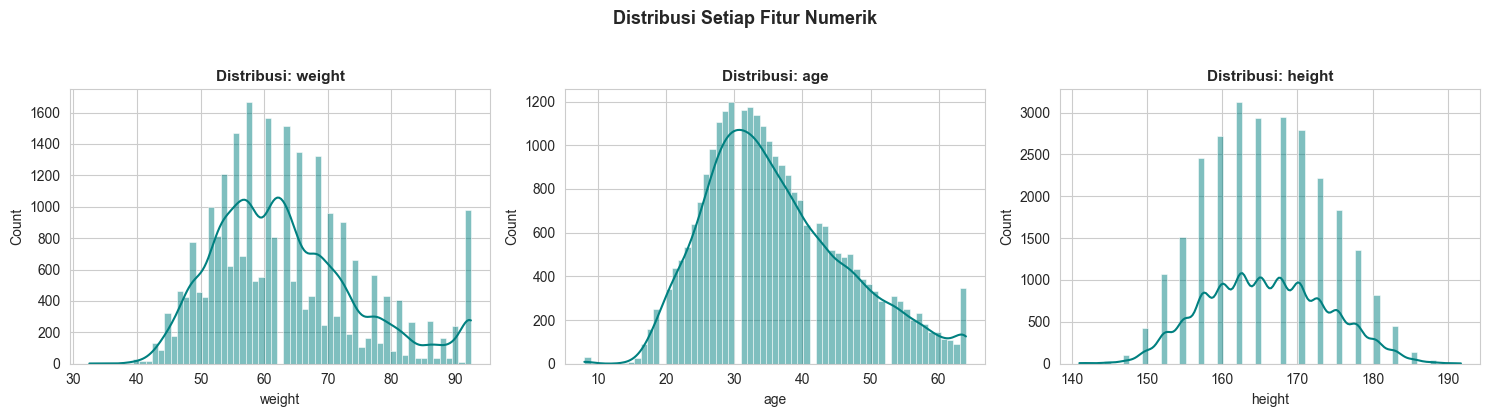

In [14]:
fig, axes = plt.subplots(1, len(kolom_numerik), figsize=(5 * len(kolom_numerik), 4))
if len(kolom_numerik) == 1:
    axes = [axes]

for ax, kolom in zip(axes, kolom_numerik):
    sns.histplot(df[kolom], kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribusi: {kolom}", fontsize=11, fontweight="bold")

plt.suptitle("Distribusi Setiap Fitur Numerik", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### **4.2 Distribusi Target (Label `size`)**

C:\Users\Asus\AppData\Local\Temp\ipykernel_10328\41993881.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="size", order=urutan_size, palette="viridis")


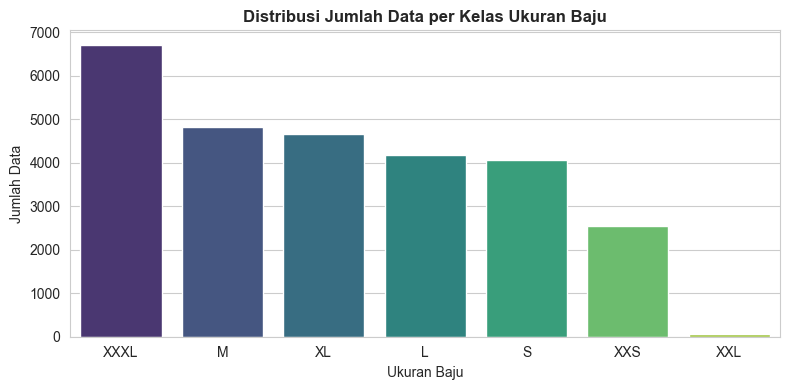

📊 Jumlah data per kelas:
size
XXXL    6703
M       4830
XL      4664
L       4174
S       4054
XXS     2549
XXL       67
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(8, 4))
urutan_size = df["size"].value_counts().index
sns.countplot(data=df, x="size", order=urutan_size, palette="viridis")
plt.title("Distribusi Jumlah Data per Kelas Ukuran Baju", fontsize=12, fontweight="bold")
plt.xlabel("Ukuran Baju")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

print("📊 Jumlah data per kelas:")
print(df["size"].value_counts())

### **4.3 Korelasi Antar Fitur Numerik**

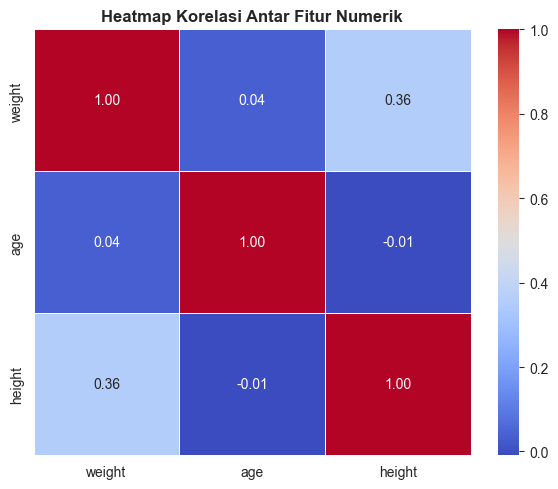

💡 Korelasi tinggi antar fitur (>0.7 atau <-0.7) berpotensi menyebabkan
   multikolinearitas -- informasi yang 'tumpang tindih' antar fitur.


In [16]:
plt.figure(figsize=(6, 5))
matriks_korelasi = df[kolom_numerik].corr()
sns.heatmap(matriks_korelasi, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur Numerik", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("💡 Korelasi tinggi antar fitur (>0.7 atau <-0.7) berpotensi menyebabkan")
print("   multikolinearitas -- informasi yang 'tumpang tindih' antar fitur.")

### **4.4 Hubungan Antar Fitur vs Target**

C:\Users\Asus\AppData\Local\Temp\ipykernel_10328\245909834.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="size", y=kolom, order=urutan_size, ax=ax, palette="Set2")
C:\Users\Asus\AppData\Local\Temp\ipykernel_10328\245909834.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="size", y=kolom, order=urutan_size, ax=ax, palette="Set2")
C:\Users\Asus\AppData\Local\Temp\ipykernel_10328\245909834.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="size", y=kolom, order=urutan_size, ax=ax, palette="Set2")


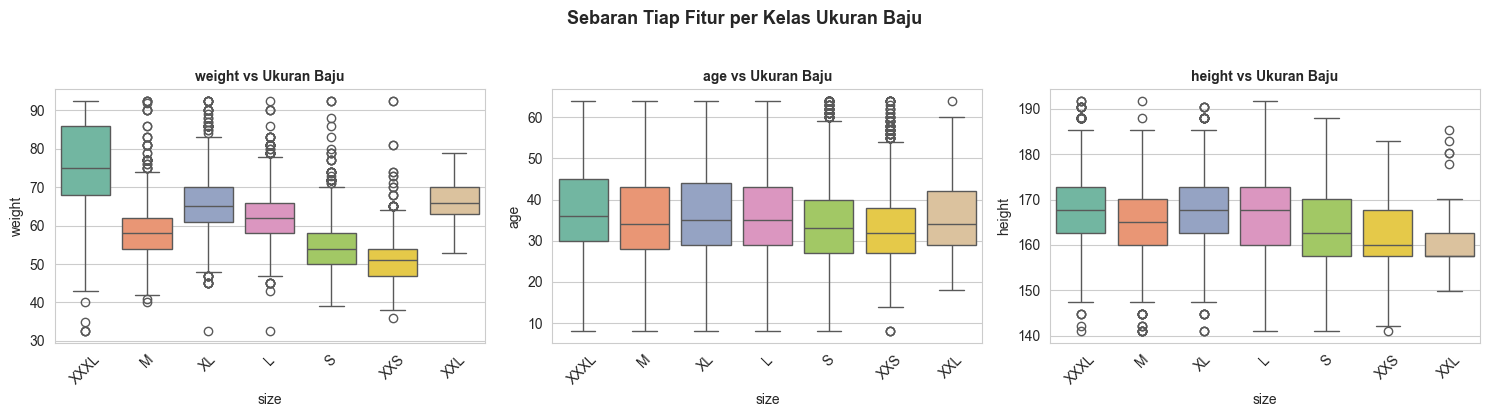

💡 Jika boxplot antar kelas terlihat jelas berbeda posisinya, berarti fitur tersebut
   punya daya pembeda (discriminative power) yang baik untuk model klasifikasi.


In [17]:
fig, axes = plt.subplots(1, len(kolom_numerik), figsize=(5 * len(kolom_numerik), 4))
if len(kolom_numerik) == 1:
    axes = [axes]

for ax, kolom in zip(axes, kolom_numerik):
    sns.boxplot(data=df, x="size", y=kolom, order=urutan_size, ax=ax, palette="Set2")
    ax.set_title(f"{kolom} vs Ukuran Baju", fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Sebaran Tiap Fitur per Kelas Ukuran Baju", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print("💡 Jika boxplot antar kelas terlihat jelas berbeda posisinya, berarti fitur tersebut")
print("   punya daya pembeda (discriminative power) yang baik untuk model klasifikasi.")

## **🛠️ 5. Feature Engineering**

Berdasarkan insight dari EDA, kita bisa menambahkan fitur turunan yang lebih bermakna secara
domain, bukan sekadar memakai fitur mentah apa adanya.

Salah satu fitur turunan yang umum dipakai pada data antropometri adalah **BMI (Body Mass
Index)** — gabungan berat & tinggi badan yang biasanya punya korelasi lebih kuat terhadap
ukuran baju dibanding berat atau tinggi badan sendiri-sendiri.

In [18]:
# Asumsi nama kolom: 'weight' (kg) dan 'height' (cm) -- sesuaikan dengan nama kolom asli dataset
kolom_berat  = [c for c in df.columns if "weight" in c.lower()]
kolom_tinggi = [c for c in df.columns if "height" in c.lower()]

print(f"Kolom berat terdeteksi  : {kolom_berat}")
print(f"Kolom tinggi terdeteksi : {kolom_tinggi}")

if kolom_berat and kolom_tinggi:
    kb, kt = kolom_berat[0], kolom_tinggi[0]
    # BMI = berat(kg) / (tinggi(m))^2
    df["bmi"] = df[kb] / ((df[kt] / 100) ** 2)
    print("\n✅ Fitur turunan 'bmi' berhasil dibuat.")
    print(df[[kb, kt, "bmi"]].head())
else:
    print("⚠️  Kolom weight/height tidak terdeteksi otomatis -- sesuaikan nama kolom secara manual.")

Kolom berat terdeteksi  : ['weight']
Kolom tinggi terdeteksi : ['height']

✅ Fitur turunan 'bmi' berhasil dibuat.
   weight  height        bmi
0    62.0  172.72  20.782914
1    59.0  167.64  20.994073
2    61.0  165.10  22.378743
3    65.0  175.26  21.161563
4    62.0  172.72  20.782914


C:\Users\Asus\AppData\Local\Temp\ipykernel_10328\2219270567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="size", y="bmi", order=urutan_size, palette="coolwarm")


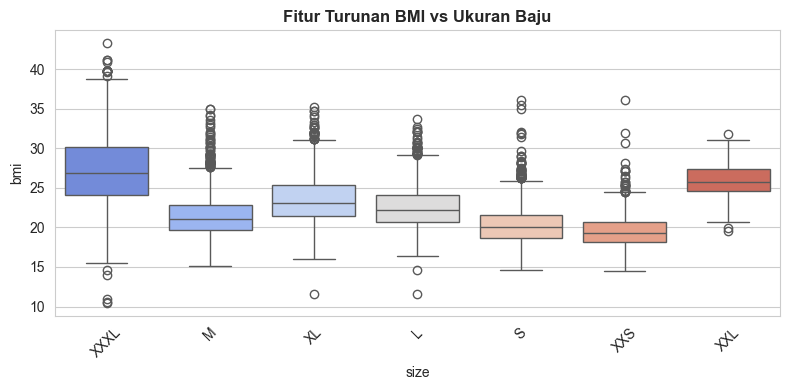

weight    0.845158
age       0.041173
height   -0.191759
bmi       1.000000
dtype: float64


In [19]:
if "bmi" in df.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="size", y="bmi", order=urutan_size, palette="coolwarm")
    plt.title("Fitur Turunan BMI vs Ukuran Baju", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(df[kolom_numerik + ["bmi"]].corrwith(df["bmi"]))

### **5.1 Encoding Label Target**

Algoritma ML klasik (seperti KNN/SVM) hanya bisa bekerja dengan angka, sehingga label kategori
`size` (S, M, L, XL, dst) perlu dikonversi menjadi angka menggunakan `LabelEncoder`.

In [20]:
label_encoder = LabelEncoder()
df["size_encoded"] = label_encoder.fit_transform(df["size"])

print("🔤 Mapping label ke angka:")
for asli, angka in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"   {asli} -> {angka}")

🔤 Mapping label ke angka:
   L -> 0
   M -> 1
   S -> 2
   XL -> 3
   XXL -> 4
   XXS -> 5
   XXXL -> 6


## **⚖️ 6. Pengecekan Class Imbalance**

Sebelum melatih model, kita WAJIB mengecek apakah jumlah data antar kelas seimbang. Jika satu
kelas mendominasi (misal kelas "M" punya 5000 data sementara kelas "XXS" cuma 20 data), model
cenderung bias menebak kelas mayoritas terus-menerus, dan terlihat "akurat" padahal sebenarnya
gagal mengenali kelas minoritas.

In [21]:
distribusi_kelas = df["size"].value_counts()
persentase_kelas = (distribusi_kelas / len(df) * 100).round(2)

ringkasan_imbalance = pd.DataFrame({
    "Jumlah Data": distribusi_kelas,
    "Persentase (%)": persentase_kelas
})

print("⚖️  RINGKASAN CLASS IMBALANCE")
print("=" * 40)
print(ringkasan_imbalance)

rasio_imbalance = distribusi_kelas.max() / distribusi_kelas.min()
print(f"\n📐 Rasio ketimpangan (kelas terbesar / kelas terkecil): {rasio_imbalance:.1f}x")

if rasio_imbalance > 3:
    print("⚠️  Ketimpangan signifikan terdeteksi (>3x) -- perlu strategi khusus saat training")
    print("   (misal: class_weight='balanced', oversampling, atau stratified split).")
else:
    print("✅ Tingkat ketimpangan masih relatif wajar.")

⚖️  RINGKASAN CLASS IMBALANCE
      Jumlah Data  Persentase (%)
size                             
XXXL         6703           24.79
M            4830           17.86
XL           4664           17.25
L            4174           15.44
S            4054           14.99
XXS          2549            9.43
XXL            67            0.25

📐 Rasio ketimpangan (kelas terbesar / kelas terkecil): 100.0x
⚠️  Ketimpangan signifikan terdeteksi (>3x) -- perlu strategi khusus saat training
   (misal: class_weight='balanced', oversampling, atau stratified split).


## **🤖 7. Pemodelan: Hello World Machine Learning**

Sekarang kita gunakan algoritma klasifikasi paling intuitif untuk pemula: **K-Nearest
Neighbors (KNN)**. Intuisinya sederhana: untuk menebak label sebuah titik data baru, KNN
melihat *K* tetangga terdekatnya di ruang fitur, lalu memilih label yang paling banyak muncul
di antara tetangga tersebut (voting mayoritas).

### **7.1 Memisahkan Fitur (X) & Target (y)**

In [22]:
fitur_terpilih = kolom_numerik + (["bmi"] if "bmi" in df.columns else [])
X = df[fitur_terpilih]
y = df["size_encoded"]

print(f"📐 Shape fitur (X) : {X.shape}")
print(f"📐 Shape target (y): {y.shape}")
print(f"\nFitur yang dipakai: {fitur_terpilih}")

📐 Shape fitur (X) : (27041, 4)
📐 Shape target (y): (27041,)

Fitur yang dipakai: ['weight', 'age', 'height', 'bmi']


### **7.2 Train-Test Split (Stratified)**

Kita gunakan `stratify=y` agar proporsi kelas di data training dan testing tetap konsisten,
mengantisipasi efek class imbalance yang sudah kita temukan sebelumnya.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📦 Data training : {X_train.shape[0]} baris")
print(f"📦 Data testing  : {X_test.shape[0]} baris")

📦 Data training : 21632 baris
📦 Data testing  : 5409 baris


### **7.3 Scaling Fitur**

KNN menghitung jarak antar titik data, sehingga sangat sensitif terhadap skala angka. Fitur
seperti `weight` (puluhan) dan `height` (ratusan) perlu diseragamkan skalanya menggunakan
`StandardScaler` agar tidak ada fitur yang mendominasi perhitungan jarak hanya karena angkanya
lebih besar.

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Fitur berhasil di-scaling (mean=0, std=1).")
print(f"   Contoh sebelum scaling: {X_train.iloc[0].values}")
print(f"   Contoh setelah scaling: {X_train_scaled[0]}")

✅ Fitur berhasil di-scaling (mean=0, std=1).
   Contoh sebelum scaling: [ 68.          31.         167.64        24.19655895]
   Contoh setelah scaling: [ 0.40862387 -0.49304015  0.22128594  0.28623497]


### **7.4 Training Model KNN**

In [25]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

print("✅ Model KNN berhasil dilatih (training selesai).")

✅ Model KNN berhasil dilatih (training selesai).


### **7.5 Evaluasi Model**

In [26]:
y_pred = model_knn.predict(X_test_scaled)

akurasi = accuracy_score(y_test, y_pred)
print(f"🎯 Akurasi model pada data testing: {akurasi:.2%}")
print()
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

🎯 Akurasi model pada data testing: 27.32%

📋 Classification Report:
              precision    recall  f1-score   support

           L       0.12      0.17      0.14       835
           M       0.14      0.17      0.15       966
           S       0.20      0.19      0.19       811
          XL       0.16      0.13      0.14       933
         XXL       0.00      0.00      0.00        13
         XXS       0.26      0.17      0.21       510
        XXXL       0.66      0.61      0.63      1341

    accuracy                           0.27      5409
   macro avg       0.22      0.20      0.21      5409
weighted avg       0.29      0.27      0.28      5409



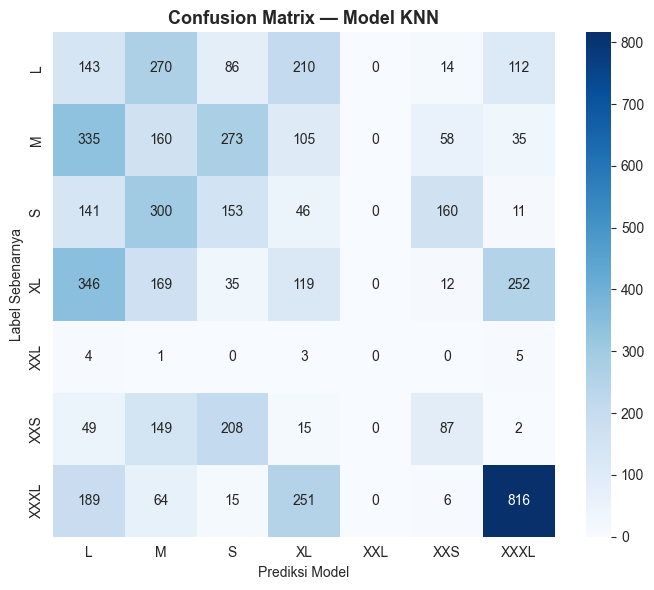

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix — Model KNN", fontsize=13, fontweight="bold")
plt.xlabel("Prediksi Model")
plt.ylabel("Label Sebenarnya")
plt.tight_layout()
plt.show()

### **7.6 Mencari Nilai K Optimal**

Nilai `K` (jumlah tetangga) sangat memengaruhi performa KNN. K terlalu kecil → model terlalu
sensitif terhadap noise (overfitting). K terlalu besar → model terlalu menggeneralisasi
(underfitting). Mari kita coba beberapa nilai K dan bandingkan akurasinya.

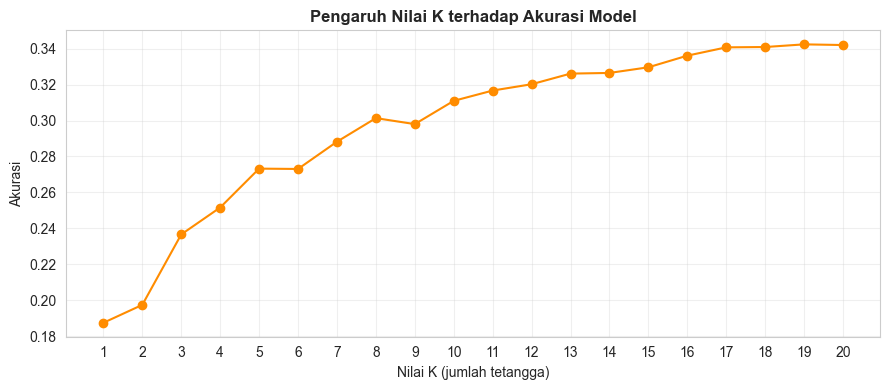

🏆 Nilai K dengan akurasi terbaik: K=19 (akurasi=34.24%)


In [28]:
daftar_k = range(1, 21)
akurasi_per_k = []

for k in daftar_k:
    model_temp = KNeighborsClassifier(n_neighbors=k)
    model_temp.fit(X_train_scaled, y_train)
    pred_temp = model_temp.predict(X_test_scaled)
    akurasi_per_k.append(accuracy_score(y_test, pred_temp))

plt.figure(figsize=(9, 4))
plt.plot(daftar_k, akurasi_per_k, marker="o", color="darkorange")
plt.title("Pengaruh Nilai K terhadap Akurasi Model", fontsize=12, fontweight="bold")
plt.xlabel("Nilai K (jumlah tetangga)")
plt.ylabel("Akurasi")
plt.xticks(list(daftar_k))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

k_terbaik = daftar_k[int(np.argmax(akurasi_per_k))]
print(f"🏆 Nilai K dengan akurasi terbaik: K={k_terbaik} (akurasi={max(akurasi_per_k):.2%})")

## **🎓 Kesimpulan Sesi 1**

Kita telah menempuh pipeline Machine Learning lengkap secara runtut:

1. **Konsep dasar** — memahami posisi AI, ML, dan DL, serta jenis data Structured vs Unstructured
2. **Data Loading** — membaca & mengenali bentuk data mentah
3. **Data Cleaning** — menangani missing values, duplikasi, dan outlier dengan alasan yang jelas
4. **EDA** — memahami distribusi fitur, target, korelasi, dan hubungan fitur terhadap label
5. **Feature Engineering** — membuat fitur turunan (BMI) dan encoding label
6. **Class Imbalance Check** — mengevaluasi keseimbangan jumlah data antar kelas
7. **Pemodelan** — melatih & mengevaluasi model KNN, termasuk tuning nilai K

💡 Di sesi berikutnya, kita akan menghadapi tantangan yang jauh lebih sulit: bagaimana jika
datanya bukan tabel rapi, melainkan **gambar** (data Unstructured)? Di situlah proses
*Feature Extraction* menjadi penting.